In [2]:
# Core
import os
import json
import math
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import requests
# Torch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# Transformers / PEFT
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from peft import LoraConfig, get_peft_model

# Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# === CONFIGURATION ===
TASK = "task1"
LLM_MODEL_ID = "Qwen/Qwen3-8B"

# BATCH_SIZE_ML = 128
# BATCH_SIZE_LLM = 32 
# EPOCHS = 5 
# OVERLAP = 0.5 # The buffer for training data (e.g., bin 4-5 sees 3.5 to 5.5)
REPO_BASE = "https://raw.githubusercontent.com/DimABSA/DimABSA2026/main/task-dataset/track_a/subtask_1"
LANGUAGES = ["eng", "jpn", "rus", 'ukr', 'zho', 'tat']
DOMAINS = ["laptop", "restaurant", "hotel", "device", "finance"]
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Running on {device}")

In [3]:
MODEL_ID = "Qwen/Qwen3-8B"
OUTPUT_DIR = "./qwen3_8b_ordinal_lora_arousal_v2"

MAX_LENGTH = 384
# BATCH_SIZE = 64          # micro-batch (QLoRA)
# GRAD_ACCUM = 1         # effective batch = 64
EPOCHS = 3
LR = 3e-5

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"

# Arousal digit space: your data min is 3.0, so make training match reality.
DIGIT_MIN = 3
DIGIT_MAX = 8
DIGITS = list(range(DIGIT_MIN, DIGIT_MAX + 1))  # [3,4,5,6,7,8]

# Soft-target shape & expected-value loss weight
SIGMA = 0.8
LAMBDA_EV = 0.4 # expected-value regression weight (0.2–0.5 are good starting points)

# Training batch sizes
PER_DEVICE_TRAIN_BS = 48
PER_DEVICE_EVAL_BS = 48
GRAD_ACCUM = 1

In [4]:

## === 1. DATA LOADING UTILITIES ===
def download_all_languages():
    """
    Crawls the repo and TAGS data with Language/Domain/Split for analysis.
    Handles '_alltasks' and '_task1' suffixes across train, dev, and test splits.
    """
    combined_data = []
    domains = ["laptop", "restaurant", "hotel", "device", "finance"] 
    suffixes = ["alltasks", "task1"]
    splits = ["train", "dev", "test"]  # Added splits
    
    print("\n--- Downloading Datasets ---")
    for lang in LANGUAGES:
        for domain in domains:
            for split in splits:
                found = False
                for suffix in suffixes:
                    # Modified filename to include dynamic {split} instead of hardcoded 'train'
                    filename = f"{lang}_{domain}_{split}_{suffix}.jsonl"
                    url = f"{REPO_BASE}/{lang}/{filename}"
                    
                    try:
                        resp = requests.get(url)
                        if resp.status_code == 200:
                            lines = resp.text.splitlines()
                            data = []
                            for line in lines:
                                row = json.loads(line)
                                row['Language'] = lang
                                row['Domain'] = domain
                                row['Split'] = split  # Tag the row with its split
                                data.append(row)
                            
                            print(f"✓ Loaded {lang}-{domain}-{split} (via {suffix}): {len(data)} samples")
                            combined_data.extend(data)
                            found = True
                            break # Stop checking suffixes if we found the file for this split
                    
                    except Exception as e:
                        print(f"Error fetching {url}: {e}")
                
                if not found:
                    # Optional: Print warning if a specific split is missing for a domain
                    # print(f"  x Missing {lang}-{domain}-{split}")
                    pass
                
    print(f"Total Combined Samples: {len(combined_data)}")
    return combined_data

def normalize_data(data):
    """
    Normalizes mixed JSONL formats into a standard DF.
    Handles 'Quadruplet' (Train), 'Aspect_VA' (Train/Dev), and 'Blind' formats (Test).
    """
    if not data:
        raise ValueError("No data downloaded! Check network or URLs.")
        
    print(f"Parsing Data from {len(data)} raw lines...")
    
    dfs = []
    
    # 1. Split data by type based on keys present
    quad_rows = [row for row in data if 'Quadruplet' in row]
    task1_rows = [row for row in data if 'Aspect_VA' in row]
    
    # Capture rows that are strictly meant for testing (marked as 'test' but missed above)
    test_rows = [
        row for row in data 
        if row['Split'] == 'test' 
        and 'Quadruplet' not in row 
        and 'Aspect_VA' not in row
    ]
    
    print(f" - Found {len(quad_rows)} Quadruplet rows")
    print(f" - Found {len(task1_rows)} Aspect_VA rows")
    print(f" - Found {len(test_rows)} Blind Test rows")

    # 2. Process Quadruplet Style
    if quad_rows:
        df_q = pd.json_normalize(
            quad_rows, 
            record_path='Quadruplet', 
            meta=['ID', 'Text', 'Language', 'Domain', 'Split']
        )
        # Parse VA: "5.5#4.0" -> [5.5, 4.0]
        df_q[['Valence', 'Arousal']] = df_q['VA'].str.split('#', expand=True).astype(float)
        dfs.append(df_q)
        
    # 3. Process Aspect_VA Style (Standard Task 1)
    if task1_rows:
        df_t = pd.json_normalize(
            task1_rows, 
            record_path='Aspect_VA', 
            meta=['ID', 'Text', 'Language', 'Domain', 'Split']
        )
        if 'Aspect' not in df_t.columns and 0 in df_t.columns:
             df_t = df_t.rename(columns={0: "Aspect"})
        
        # Parse VA
        df_t[['Valence', 'Arousal']] = df_t['VA'].str.split('#', expand=True).astype(float)
        dfs.append(df_t)

    # 4. Process Blind Test Data (Sample: {"Aspect": ["pizza", "sauce"], "Text": "...", "ID": "..."})
    if test_rows:
        try:
            df_test = pd.DataFrame(test_rows)
            
            # CRITICAL FIX: Explode the list of aspects into separate rows
            if 'Aspect' in df_test.columns:
                 df_test = df_test.explode('Aspect')
            
            # Add Dummy Columns for VA (Test set has no ground truth)
            # We set them to -1.0 to make it obvious they are dummies
            df_test['Valence'] = -1.0
            df_test['Arousal'] = -1.0
                
            dfs.append(df_test)
            
        except Exception as e:
            print(f"⚠️ Error parsing Test rows: {e}")

    if not dfs:
        raise ValueError("Unknown JSON format. No valid rows parsed.")
        
    # 5. Merge
    df = pd.concat(dfs, ignore_index=True)
    
    # Ensure all required columns exist
    required_cols = ['ID', 'Text', 'Aspect', 'Valence', 'Arousal', 'Language', 'Domain', 'Split']
    for col in required_cols:
        if col not in df.columns:
            df[col] = np.nan 

    return df[required_cols].copy()


# === 2. DATA PREPROCESSING & BINNING ===
def assign_bin_category(arousal: float) -> str:
    if arousal < 3.0:
        return "[BIN_A]"
    elif arousal < 6.0:
        return "[BIN_B]"
    else:
        return "[BIN_C]"

In [ ]:
def clean_aspect(x):
    if pd.isna(x) or str(x).upper() == "NULL":
        return "general sentiment"
    return str(x)

raw_data = download_all_languages()
df = normalize_data(raw_data)

df["Aspect"] = df["Aspect"].apply(clean_aspect)
labeled_df = df[(df["Split"] == "train") & (df["Arousal"] >= 0)].copy()
train_df, val_df = train_test_split(labeled_df, test_size=0.1, random_state=SEED)

print("\nData Partitioning:")
print("  Train source labeled:", len(labeled_df))
print("  Train split:", len(train_df))
print("  Val split:", len(val_df))

# # Convert arousal → integer bin
# df["label"] = np.floor(df["Arousal"]).clip(1, 8).astype(int)
# # 1. Separate the official repo splits
# # We use only the official 'train' data for the model's training/validation pipeline below.
# train_source_df = df[df['Split'] == 'train'].copy()

# # We store the official Dev and Test sets separately for later use.
# official_dev_df = df[df['Split'] == 'dev'].copy()
# official_test_df = df[df['Split'] == 'test'].copy()

# print(f"\nData Partitioning:")
# print(f"  Official Training Source: {len(train_source_df)}")
# print(f"  Official Dev Set (Saved): {len(official_dev_df)}")
# print(f"  Official Test Set (Saved): {len(official_test_df)}")


# train_df, val_df = train_test_split(train_source_df, test_size=0.1, random_state=SEED)


--- Downloading Datasets ---
✓ Loaded eng-laptop-train (via alltasks): 4076 samples
✓ Loaded eng-laptop-dev (via task1): 200 samples
✓ Loaded eng-laptop-test (via task1): 1000 samples
✓ Loaded eng-restaurant-train (via alltasks): 2284 samples
✓ Loaded eng-restaurant-dev (via task1): 200 samples
✓ Loaded eng-restaurant-test (via task1): 1000 samples
✓ Loaded jpn-hotel-train (via alltasks): 1600 samples
✓ Loaded jpn-hotel-dev (via task1): 200 samples
✓ Loaded jpn-hotel-test (via task1): 800 samples
✓ Loaded jpn-finance-train (via task1): 1024 samples
✓ Loaded jpn-finance-dev (via task1): 200 samples
✓ Loaded jpn-finance-test (via task1): 800 samples
✓ Loaded rus-restaurant-train (via alltasks): 1240 samples
✓ Loaded rus-restaurant-dev (via task1): 56 samples
✓ Loaded rus-restaurant-test (via task1): 1072 samples
✓ Loaded ukr-restaurant-train (via alltasks): 1240 samples
✓ Loaded ukr-restaurant-dev (via task1): 56 samples
✓ Loaded ukr-restaurant-test (via task1): 1072 samples
✓ Loaded zh

In [21]:
df.to_csv("github_datasets/train_source_df.csv", index=False)
df.to_csv("github_datasets/official_dev_df.csv", index=False)
df.to_csv("github_datasets/official_test_df.csv", index=False)

In [6]:
def build_prompt(text, aspect, language, domain):
    return f"""You are a sentiment classification system.

Task:
Given a text and an aspect, output a single integer from {DIGIT_MIN} to
{DIGIT_MAX} representing the arousal expressed toward the aspect.

Output rules:
- Output exactly ONE integer
- No explanation
- No additional text

Language: {language}
Domain: {domain}
Text: {text}
Aspect: {aspect}

Output: """

# def ordinal_soft_target_from_float(arousal, num_bins=8, sigma=1.0):
#     """
#     Create an ordinal soft target from float arousal.
#     """
#     bins = np.arange(1, num_bins + 1)
#     probs = np.exp(-((bins - arousal) ** 2) / (2 * sigma ** 2))
#     probs /= probs.sum()
#     return probs

In [7]:
def clip_arousal(a):
    # Data min is 3.0; keep targets inside [3,8]
    return float(np.clip(a, DIGIT_MIN, DIGIT_MAX))


def target_digit_from_float(a):
    # Use round (less biased than floor). Still clip to [3,8].
    d = int(np.rint(a))
    return int(np.clip(d, DIGIT_MIN, DIGIT_MAX))


def soft_target_over_digits(a_float, sigma=SIGMA):
    """
    Gaussian-shaped soft target over DIGITS (3..8), centered at the float arousal.
    Returns probs shape [K].
    """
    a = clip_arousal(a_float)
    bins = np.array(DIGITS, dtype=np.float32)  # [3,4,5,6,7,8]
    probs = np.exp(-((bins - a) ** 2) / (2 * sigma ** 2)).astype(np.float32)
    probs /= probs.sum()
    return probs

In [8]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    trust_remote_code=True
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True, 
    attn_implementation="flash_attention_2"
)

Loading checkpoint shards: 100%|██████████| 5/5 [00:03<00:00,  1.47it/s]


In [9]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ]
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.config.use_cache = False
# try:
#     model = torch.compile(model)
#     print("torch.compile enabled.")
# except Exception as e:
#     print("torch.compile skipped:", repr(e))

trainable params: 43,646,976 || all params: 8,234,382,336 || trainable%: 0.5301


In [10]:
DIGIT_TOKEN_IDS = [tokenizer(str(d), add_special_tokens=False)["input_ids"][0] for d in DIGITS]

def preprocess_data(df_in, tokenizer):
    tokenized = []
    for _, row in tqdm(df_in.iterrows(), total=len(df_in), desc="Tokenizing"):
        prompt = build_prompt(row["Text"], row["Aspect"], row["Language"], row["Domain"])
        enc = tokenizer(
            prompt,
            truncation=True,
            max_length=MAX_LENGTH,
            padding=False,
            return_tensors="pt",
        )

        a_float = clip_arousal(float(row["Arousal"]))
        soft_t = soft_target_over_digits(a_float, sigma=SIGMA)

        tokenized.append(
            {
                "input_ids": enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0),
                "soft_target": torch.tensor(soft_t, dtype=torch.float32),
                "arousal_float": torch.tensor(a_float, dtype=torch.float32),
            }
        )
    return tokenized

class PreTokenizedDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]


train_tokenized = preprocess_data(train_df, tokenizer)
val_tokenized = preprocess_data(val_df, tokenizer)

# SUBSET_SIZE = 256   # ~2–3 minutes on A100
# train_df_small = train_df.sample(n=SUBSET_SIZE, random_state=42).reset_index(drop=True)
# val_df_small   = val_df.sample(n=64, random_state=42).reset_index(drop=True)
# train_tokenized_small = preprocess_data(train_df_small, tokenizer)
# val_tokenized_small   = preprocess_data(val_df_small, tokenizer)

train_ds = PreTokenizedDataset(train_tokenized)
val_ds = PreTokenizedDataset(val_tokenized)
# train_ds = PreTokenizedDataset(train_tokenized_small)
# val_ds   = PreTokenizedDataset(val_tokenized_small)

Tokenizing:   0%|          | 0/35162 [00:00<?, ?it/s]

Tokenizing: 100%|██████████| 3907/3907 [00:03<00:00, 1092.36it/s]


In [11]:
# LOSS: soft ordinal CE over digits 3..8 + expected-value regression
def soft_ce_over_digits(next_token_logits, soft_target):
    """
    next_token_logits: [B, vocab]
    soft_target: [B, K] over digits 3..8
    """
    digit_logits = next_token_logits[:, DIGIT_TOKEN_IDS]  # [B, K]
    log_probs = F.log_softmax(digit_logits, dim=-1)       # [B, K]
    loss = -(soft_target.to(log_probs.device) * log_probs).sum(dim=-1).mean()
    return loss, digit_logits

def expected_value_from_digit_logits(digit_logits):
    """
    digit_logits: [B, K] logits for digits 3..8
    returns:
      probs: [B, K]
      exp_score: [B]
      p_low: [B]  where low means digit < 6
    """
    probs = F.softmax(digit_logits, dim=-1)  # [B, K]
    digits = torch.tensor(DIGITS, device=probs.device, dtype=probs.dtype)  # [K]
    exp_score = (probs * digits).sum(dim=-1)

    # low is 3,4,5 (if present)
    # indices 0..(5-DIGIT_MIN)
    if DIGIT_MIN <= 5:
        k_low = min(5, DIGIT_MAX) - DIGIT_MIN + 1
        p_low = probs[:, :k_low].sum(dim=-1)
    else:
        p_low = torch.zeros(probs.shape[0], device=probs.device, dtype=probs.dtype)

    return probs, exp_score, p_low

# Sampler for balanced language sampling
from collections import Counter
from torch.utils.data import WeightedRandomSampler

def make_lang_bin_weights(df_in):
    # df_in must be exactly what you tokenized, in the same order
    langs = df_in["Language"].tolist()
    sides = (df_in["Arousal"].astype(float) < 6.0).map({True: "lt6", False: "ge6"}).tolist()
    keys = list(zip(langs, sides))
    counts = Counter(keys)
    w = np.array([1.0 / counts[k] for k in keys], dtype=np.float32)
    w = w / w.mean()
    return torch.tensor(w, dtype=torch.float32)

train_weights = make_lang_bin_weights(train_df)
sampler = WeightedRandomSampler(train_weights, num_samples=len(train_weights), replacement=True)

# def make_language_weights_from_df(df_in):
#     langs = df_in["Language"].tolist()
#     counts = Counter(langs)
#     weights = np.array([1.0 / counts[l] for l in langs], dtype=np.float32)
#     weights = weights / weights.mean()  # optional normalization
#     return torch.tensor(weights, dtype=torch.float32)

# train_weights = make_language_weights_from_df(train_df_small)

# assert len(train_weights) == len(train_tokenized_small), f"{len(train_weights)} vs {len(train_tokenized_small)}"
# assert len(train_weights) == len(train_ds), f"{len(train_weights)} vs {len(train_ds)}"

# sampler = WeightedRandomSampler(
#     weights=train_weights,
#     num_samples=len(train_weights),
#     replacement=True
# )


In [12]:
# =========================
# 8) CUSTOM TRAINER
# =========================
class ArousalOrdinalTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        soft_target = inputs.pop("soft_target")          # [B, K]
        arousal_float = inputs.pop("arousal_float")      # [B]

        input_ids = inputs["input_ids"]
        attention_mask = inputs["attention_mask"]

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        # logits shape: [B, T, vocab]
        logits = outputs.logits

        # IMPORTANT: pick logits at the last REAL token position (not at padded -1)
        # pos[i] = index of last token in each sequence
        pos = attention_mask.sum(dim=1) - 1  # [B]
        batch_idx = torch.arange(logits.size(0), device=logits.device)

        next_logits = logits[batch_idx, pos, :]  # [B, vocab]

        loss_ce, digit_logits = soft_ce_over_digits(next_logits, soft_target)
        probs, exp_score, p_low = expected_value_from_digit_logits(digit_logits)

        loss_ev = F.mse_loss(exp_score.float(), arousal_float.to(exp_score.device).float())
        loss = loss_ce + (LAMBDA_EV * loss_ev)

        return (loss, outputs) if return_outputs else loss

    def get_train_dataloader(self):
        # Use our weighted sampler to balance languages
        data_collator = self.data_collator
        return DataLoader(
            self.train_dataset,
            batch_size=self.args.per_device_train_batch_size,
            sampler=sampler,
            collate_fn=data_collator,
            num_workers=self.args.dataloader_num_workers,
            pin_memory=self.args.dataloader_pin_memory,
        )

In [13]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=PER_DEVICE_TRAIN_BS,
    per_device_eval_batch_size=PER_DEVICE_EVAL_BS,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    num_train_epochs=EPOCHS,
    logging_steps=20,
    eval_strategy="no",
    save_strategy="epoch",
    logging_strategy="epoch",
    bf16=True,
    tf32=True,
    report_to="none",
    save_total_limit=1,
    remove_unused_columns=False,
    gradient_checkpointing=True,
    dataloader_num_workers=4,
    dataloader_pin_memory=True,
    optim="adamw_torch_fused",
)


data_collator = DataCollatorWithPadding(tokenizer=tokenizer, pad_to_multiple_of=8)

trainer = ArousalOrdinalTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    processing_class=tokenizer,
)



The model is already on multiple devices. Skipping the move to device specified in `args`.


In [14]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
733,1.500100
1466,1.328000
2199,1.283900


TrainOutput(global_step=2199, training_loss=1.3706550962440314, metrics={'train_runtime': 10715.9871, 'train_samples_per_second': 9.844, 'train_steps_per_second': 0.205, 'total_flos': 1.213302217577595e+18, 'train_loss': 1.3706550962440314, 'epoch': 3.0})

In [15]:
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

('./qwen3_8b_ordinal_lora_arousal_v2/tokenizer_config.json',
 './qwen3_8b_ordinal_lora_arousal_v2/special_tokens_map.json',
 './qwen3_8b_ordinal_lora_arousal_v2/chat_template.jinja',
 './qwen3_8b_ordinal_lora_arousal_v2/vocab.json',
 './qwen3_8b_ordinal_lora_arousal_v2/merges.txt',
 './qwen3_8b_ordinal_lora_arousal_v2/added_tokens.json',
 './qwen3_8b_ordinal_lora_arousal_v2/tokenizer.json')

NameError: name 'AutoModelForCausalLM' is not defined

In [16]:

# %%
# =========================
# 10) INFERENCE HELPERS: soft probabilities to feed your ML model
# =========================
@torch.no_grad()
def arousal_guidance_from_prompts(model, tokenizer, prompts, max_length=MAX_LENGTH):
    enc = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=max_length,
    ).to(model.device)

    out = model(**enc)

    logits = out.logits  # [B, T, vocab]
    attn = enc["attention_mask"]

    pos = attn.sum(dim=1) - 1
    batch_idx = torch.arange(logits.size(0), device=logits.device)
    next_logits = logits[batch_idx, pos, :]  # [B, vocab]

    digit_logits = next_logits[:, DIGIT_TOKEN_IDS]
    probs, exp_score, p_low = expected_value_from_digit_logits(digit_logits)

    hard_idx = probs.argmax(dim=-1)
    hard_digit = torch.tensor(DIGITS, device=probs.device)[hard_idx]
    hard_bin = ["[BIN_B]" if int(d.item()) < 6 else "[BIN_C]" for d in hard_digit]

    return probs.detach().cpu(), exp_score.detach().cpu(), p_low.detach().cpu(), hard_digit.detach().cpu(), hard_bin

def format_arousal_guidance_text(p_low, exp_score, probs=None):
    """
    Create a short guidance header string you can prepend to the multilingual-e5 input.
    Keep it compact: two scalars. Optionally include full dist.
    """
    # Two-scalar version (recommended first)
    base = f"AROUSAL_PLOW: {p_low:.3f} AROUSAL_SCORE: {exp_score:.3f}"
    if probs is None:
        return base
    # Full dist (optional)
    dist_parts = [f"{d}={probs[i]:.3f}" for i, d in enumerate(DIGITS)]
    return base + " AROUSAL_DIST: " + " ".join(dist_parts)


# %%
# =========================
# 11) QUICK DEMO: compute guidance for a few validation rows
# =========================
demo = val_df.sample(n=5, random_state=SEED).copy()
demo_prompts = [
    build_prompt(r.Text, r.Aspect, r.Language, r.Domain)
    for r in demo.itertuples(index=False)
]

probs, exp_score, p_low, hard_digit, hard_bin = arousal_guidance_from_prompts(
    model, tokenizer, demo_prompts
)

demo["arousal_true"] = demo["Arousal"].astype(float)
demo["llm_digit"] = hard_digit.numpy()
demo["llm_bin_bc"] = hard_bin
demo["llm_p_low"] = p_low.numpy()
demo["llm_exp_score"] = exp_score.numpy()

# If you want the full dist as a string column:
demo["llm_dist_str"] = [
    " ".join([f"{d}={probs[j,i]:.3f}" for i,d in enumerate(DIGITS)])
    for j in range(probs.shape[0])
]

display(demo[["Language","Domain","Aspect","arousal_true","llm_digit","llm_bin_bc","llm_p_low","llm_exp_score","llm_dist_str"]])


/home/modim2/miniforge3/envs/hf-fa-py311/lib/python3.11/site-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


,Language,Domain,Aspect,arousal_true,llm_digit,llm_bin_bc,llm_p_low,llm_exp_score,llm_dist_str
8564,eng,restaurant,service,5.75,6,[BIN_C],0.296768,6.137877,3=0.005 4=0.071 5=0.220 6=0.320 7=0.249 8=0.134
26682,zho,restaurant,牛肉爐,6.17,6,[BIN_C],0.207528,6.164987,3=0.001 4=0.022 5=0.184 6=0.442 7=0.304 8=0.047
29772,zho,restaurant,魚皮湯,6.17,7,[BIN_C],0.066644,6.829351,3=0.000 4=0.004 5=0.062 6=0.280 7=0.407 8=0.247
14942,ukr,restaurant,пивна карта,6.75,6,[BIN_C],0.175170,6.251265,3=0.000 4=0.015 5=0.160 6=0.435 7=0.338 8=0.052
3378,eng,laptop,general sentiment,7.33,7,[BIN_C],0.026738,7.225856,3=0.000 4=0.003 5=0.024 6=0.136 7=0.419 8=0.419


In [19]:
def eval_guidance(df_eval, name="eval"):
    mini = df_eval.copy()
    prompts = [build_prompt(r.Text, r.Aspect, r.Language, r.Domain) for r in mini.itertuples(index=False)]
    probs, exp_score, p_low, hard_digit, hard_bin = arousal_guidance_from_prompts(model, tokenizer, prompts)

    y_true = mini["Arousal"].astype(float).clip(3,8).values
    y_pred = exp_score.numpy()

    rmse = np.sqrt(((y_pred - y_true)**2).mean())
    pcc = np.corrcoef(y_pred, y_true)[0,1] if len(y_true) > 1 else float("nan")

    print(f"\n[{name}] n={len(mini)}")
    print(" true mean/std:", y_true.mean(), y_true.std())
    print(" pred mean/std:", y_pred.mean(), y_pred.std())
    print(" RMSE:", rmse)
    print(" PCC:", pcc)

# After some training steps / epochs:
# eval_guidance(train_df, "train_small (overfit target)")
eval_guidance(val_df,   "val_small")

OutOfMemoryError: CUDA out of memory. Tried to allocate 5.72 GiB. GPU 0 has a total capacity of 79.25 GiB of which 5.31 GiB is free. Including non-PyTorch memory, this process has 73.94 GiB memory in use. Of the allocated memory 73.22 GiB is allocated by PyTorch, and 219.86 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [31]:
import re

@torch.no_grad()
def gen_digit(model, tokenizer, prompt):
    # constrain generation to 1 token and read text
    enc = tokenizer(prompt, return_tensors="pt").to(model.device)
    out = model.generate(
        **enc,
        max_new_tokens=1,
        do_sample=False,
        return_dict_in_generate=True,
        output_scores=True,
    )
    txt = tokenizer.decode(out.sequences[0][enc["input_ids"].shape[1]:], skip_special_tokens=True)
    m = re.search(r"[0-9]", txt)
    return m.group(0) if m else txt.strip()

@torch.no_grad()
def forward_argmax_digit(model, tokenizer, prompt):
    enc = tokenizer(prompt, return_tensors="pt").to(model.device)
    out = model(**enc)
    logits = out.logits[:, -1, :]  # our assumed next-token position
    digit_logits = logits[:, DIGIT_TOKEN_IDS]
    probs = torch.softmax(digit_logits, dim=-1)[0]
    hard = DIGITS[int(torch.argmax(probs).item())]
    return str(hard), probs.detach().cpu().numpy()

# run on 5 examples
mini = val_df.sample(n=5, random_state=SEED)
for r in mini.itertuples(index=False):
    p = build_prompt(r.Text, r.Aspect, r.Language, r.Domain)
    g = gen_digit(model, tokenizer, p)
    f, pr = forward_argmax_digit(model, tokenizer, p)
    print("gen:", g, " forward:", f, " top probs:", {d: float(pr[i]) for i,d in enumerate(DIGITS)})

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
Caching is incompatible with gradient checkpointing in Qwen3DecoderLayer. Setting `past_key_values=None`.
/home/modim2/miniforge3/envs/hf-fa-py311/lib/python3.11/site-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/home/modim2/miniforge3/envs/hf-fa-py311/lib/python3.11/site-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


gen: 3  forward: 3  top probs: {3: 0.9815612435340881, 4: 0.010904161259531975, 5: 0.004545530769973993, 6: 0.0018948590150102973, 7: 0.0006151706329546869, 8: 0.00047909541171975434}


/home/modim2/miniforge3/envs/hf-fa-py311/lib/python3.11/site-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


gen: 7  forward: 7  top probs: {3: 0.01762186363339424, 4: 0.0030622202903032303, 5: 0.02262692153453827, 6: 0.3123549818992615, 7: 0.4010717272758484, 8: 0.24326230585575104}
gen: 8  forward: 8  top probs: {3: 0.00046576527529396117, 4: 0.00024930620566010475, 5: 0.0009860250866040587, 6: 0.03265266492962837, 7: 0.3097998797893524, 8: 0.655846357345581}
gen: 6  forward: 6  top probs: {3: 0.08625480532646179, 4: 0.024712415412068367, 5: 0.26568350195884705, 6: 0.3010588586330414, 7: 0.1611451953649521, 8: 0.1611451953649521}
gen: 6  forward: 6  top probs: {3: 0.002641417784616351, 4: 0.001247717416845262, 5: 0.019517583772540092, 6: 0.5033650994300842, 7: 0.3459574580192566, 8: 0.1272706389427185}


In [20]:
# SamplingParams(
#     temperature=0.0,
#     top_p=1.0,
#     max_tokens=1
# )

In [25]:
example = val_df_small.iloc[60]

prompt = build_prompt(example["Text"], example["Aspect"])

inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

with torch.no_grad():
    out = model.generate(
        **inputs,
        max_new_tokens=1,
        temperature=0.1
    )

print(tokenizer.decode(out[0]))
print("GT:", int(np.floor(example["Arousal"])))

You are a sentiment classification system.

Task:
Given a text and an aspect, output a single integer from 1 to 8
representing the arousal expressed toward the aspect.

Output rules:
- Output exactly ONE integer
- No explanation
- No additional text

Text: 鮮蚵滷肉飯真的很普通，底層的肉燥死鹹。
Aspect: 肉燥

Output: 5
GT: 5


In [ ]:
example = val_df_small.iloc[60]

prompt = build_prompt(example["Text"], example["Aspect"])

inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

with torch.no_grad():
    out = model.generate(
        **inputs,
        max_new_tokens=1,
        temperature=0.1
    )

print(tokenizer.decode(out[0]))
print("GT:", int(np.floor(example["Arousal"])))

You are a sentiment classification system.

Task:
Given a text and an aspect, output a single integer from 1 to 8
representing the arousal expressed toward the aspect.

Output rules:
- Output exactly ONE integer
- No explanation
- No additional text

Text: 鮮蚵滷肉飯真的很普通，底層的肉燥死鹹。
Aspect: 肉燥

Output: 5
GT: 5


In [22]:
def manual_eval_loss_and_rmse(model, dl, tokenizer):
    model.eval()
    digit_ids = [tokenizer(str(i), add_special_tokens=False)["input_ids"][0] for i in range(1,9)]
    losses = []
    y_true = []
    y_pred = []

    with torch.no_grad():
        for batch in dl:
            soft = batch["soft_target"]
            batch = {k:v.to("cuda") for k,v in batch.items() if torch.is_tensor(v)}
            soft = soft.to("cuda")

            out = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
            logits = out.logits[:, -2, :]

            # loss
            loss = ordinal_soft_ce_loss(logits, soft, tokenizer)
            losses.append(loss.item())

            # predictions
            digit_logits = logits[:, digit_ids]
            pred = digit_logits.argmax(dim=-1).cpu().numpy() + 1

            # true bins from soft target expected value
            exp_val = (soft.cpu().numpy() * np.arange(1,9)[None,:]).sum(axis=1)
            true_bin = np.floor(exp_val).clip(1,8).astype(int)

            y_true.append(true_bin)
            y_pred.append(pred)

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(1,9))
    return float(np.mean(losses)), rmse, cm

val_dl = trainer.get_eval_dataloader(val_ds)
eval_loss, rmse, cm = manual_eval_loss_and_rmse(model_eager, val_dl, tokenizer)
print("eval_loss:", eval_loss, "rmse:", rmse)
print(cm)

NameError: name 'model_eager' is not defined

In [15]:
# # %%
# # Clear cache if needed.
# try:
#     del llm_engine
#     # del optimizer
#     gc.collect()

# except NameError:
#     pass # Variables might not exist, that's fine
torch.cuda.empty_cache()

In [62]:
def coarsen_bin(x):
    """
    Coarsen numeric bins into:
    A: < 3
    B: < 6
    C: <= 9
    """
    if not np.isfinite(x):
        return np.nan
    if x < 3:
        return 'A'
    elif x < 6:
        return 'B'
    else:
        return 'C'

In [63]:
test_with_preds['pred_v_bin'] = pd.to_numeric(test_with_preds['pred_v_bin'], errors='coerce')


==================== Valence: LLM vs Ground Truth ====================
RMSE (Average Bin Distance): 1.1663
------------------------------------------------------------
Detailed Classification Report:
              precision    recall  f1-score   support

           1       0.12      0.72      0.20        18
           2       0.22      0.13      0.17       112
           3       0.30      0.56      0.39       291
           4       0.28      0.05      0.09       427
           5       0.35      0.47      0.40       563
           6       0.53      0.29      0.38      1331
           7       0.37      0.52      0.43       771
           8       0.20      0.41      0.27       146

    accuracy                           0.36      3659
   macro avg       0.30      0.40      0.29      3659
weighted avg       0.40      0.36      0.35      3659

------------------------------------------------------------


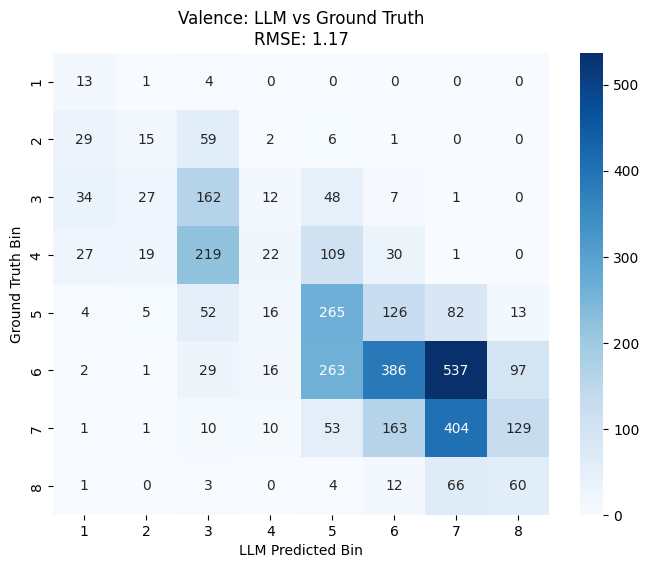

In [ ]:
# 1. Robust calculation of Ground Truth Bins
# test_with_preds['true_v_bin'] = np.floor(pd.to_numeric(test_with_preds['Valence'], errors='coerce')).fillna(5).astype(int)
test_with_preds['true_a_bin'] = np.floor(pd.to_numeric(test_with_preds['Arousal'], errors='coerce')).fillna(5).astype(int)

# Cap at 8 (since bin 9 isn't usually a full bin in this specific logic, or to match 1-8 logic)
# test_with_preds['true_v_bin'] = test_with_preds['true_v_bin'].clip(1, 8)
test_with_preds['true_a_bin'] = test_with_preds['true_a_bin'].clip(1, 8)

# 2. Ensure Predictions are numeric
# test_with_preds['pred_v_bin'] = pd.to_numeric(test_with_preds['pred_v_bin'], errors='coerce')
test_with_preds['pred_a_bin'] = pd.to_numeric(test_with_preds['pred_a_bin'], errors='coerce')

def plot_cm_with_metrics(y_true, y_pred, title):
    # Convert to numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Create mask for valid data
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    
    # Count dropped rows
    dropped_count = len(y_true) - np.sum(mask)
    if dropped_count > 0:
        print(f"[{title}] Warning: Dropped {dropped_count} rows containing NaN/Inf values.")
    
    # Filter arrays
    y_true_clean = y_true[mask].astype(int)
    y_pred_clean = y_pred[mask].astype(int)
    
    if len(y_true_clean) == 0:
        print(f"[{title}] Error: No valid data points left to analyze.")
        return

    # === METRICS CALCULATION ===
    
    # 1. RMSE (Average Distance)
    # This treats the bins as regression values to see "how far off" we are on average
    rmse = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
    
    # 2. Classification Report (Precision, Recall, F1)
    # zero_division=0 prevents warnings for empty bins
    report = classification_report(y_true_clean, y_pred_clean, labels=range(1, 9), zero_division=0)
    
    print(f"\n{'='*20} {title} {'='*20}")
    print(f"RMSE (Average Bin Distance): {rmse:.4f}")
    print("-" * 60)
    print("Detailed Classification Report:")
    print(report)
    print("-" * 60)

    # === PLOTTING ===
    cm = confusion_matrix(y_true_clean, y_pred_clean, labels=range(1, 9))
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(1,9), yticklabels=range(1,9))
    plt.xlabel('LLM Predicted Bin')
    plt.ylabel('Ground Truth Bin')
    plt.title(f"{title}\nRMSE: {rmse:.2f}") # Added RMSE to title for easy viewing
    plt.show()

# Run the Updated Plotter
plot_cm_with_metrics(test_with_preds['true_v_bin'], test_with_preds['pred_v_bin'], "Valence: LLM vs Ground Truth")
# plot_cm_with_metrics(test_with_preds['true_a_bin'], test_with_preds['pred_a_bin'], "Arousal: LLM vs Ground Truth")

In [66]:
for col in ['true_v_bin', 'pred_v_bin']:
    test_with_preds[f'{col}_coarse'] = test_with_preds[col].apply(coarsen_bin)


In [67]:
test_with_preds.to_json("test_llm_full_predictions.jsonl", orient="records", lines=True)

In [57]:
def plot_cm_with_metrics_coarse(y_true, y_pred, title, labels=None, compute_rmse=True):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = pd.notna(y_true) & pd.notna(y_pred)
    dropped = len(y_true) - mask.sum()
    if dropped > 0:
        print(f"[{title}] Dropped {dropped} invalid rows.")

    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if len(y_true) == 0:
        print(f"[{title}] No valid data.")
        return

    print(f"\n{'='*20} {title} {'='*20}")

    rmse = None
    if compute_rmse:
        rmse = np.sqrt(mean_squared_error(y_true.astype(float), y_pred.astype(float)))
        print(f"RMSE: {rmse:.4f}")

    print("-" * 60)
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))
    print("-" * 60)

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels
    )
    plt.xlabel("Predicted")
    plt.ylabel("Ground Truth")
    title_suffix = f"\nRMSE: {rmse:.2f}" if rmse is not None else ""
    plt.title(title + title_suffix)
    plt.show()

    
def run_all_slices(
    df,
    true_col,
    pred_col,
    base_title,
    labels,
    compute_rmse=True
):
    # Overall
    plot_cm_with_metrics_coarse(
        df[true_col],
        df[pred_col],
        f"{base_title} (Overall)",
        labels=labels,
        compute_rmse=compute_rmse
    )

    # Per Language
    if 'Language' in df.columns:
        for lang, g in df.groupby('Language'):
            plot_cm_with_metrics_coarse(
                g[true_col],
                g[pred_col],
                f"{base_title} | Language={lang}",
                labels=labels,
                compute_rmse=compute_rmse
            )

    # Per Domain
    if 'Domain' in df.columns:
        for dom, g in df.groupby('Domain'):
            plot_cm_with_metrics_coarse(
                g[true_col],
                g[pred_col],
                f"{base_title} | Domain={dom}",
                labels=labels,
                compute_rmse=compute_rmse
            )



==================== Valence (1–8 bins) (Overall) ====================
RMSE: 1.1664
------------------------------------------------------------
              precision    recall  f1-score   support

           1       0.12      0.72      0.20        18
           2       0.20      0.12      0.15       112
           3       0.30      0.56      0.39       291
           4       0.29      0.05      0.09       427
           5       0.36      0.48      0.41       563
           6       0.54      0.30      0.38      1331
           7       0.37      0.53      0.43       771
           8       0.21      0.42      0.28       146

    accuracy                           0.37      3659
   macro avg       0.30      0.40      0.29      3659
weighted avg       0.40      0.37      0.35      3659

------------------------------------------------------------


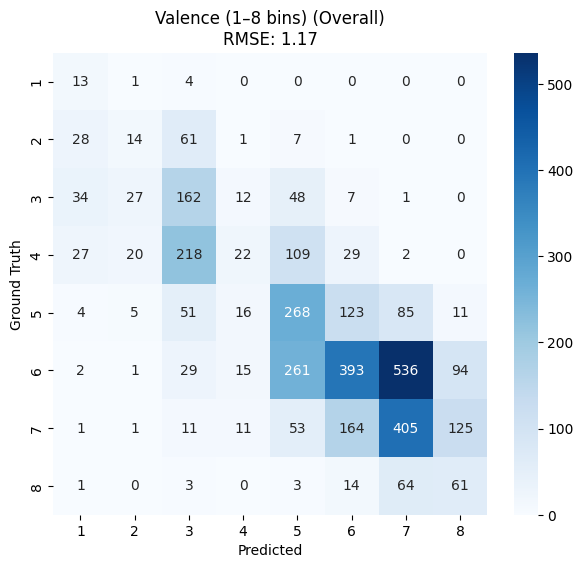


==================== Valence (1–8 bins) | Language=eng ====================
RMSE: 1.2881
------------------------------------------------------------
              precision    recall  f1-score   support

           1       0.13      0.89      0.22         9
           2       0.23      0.21      0.22        57
           3       0.27      0.53      0.36        89
           4       0.12      0.02      0.04       121
           5       0.35      0.35      0.35       120
           6       0.34      0.38      0.36       141
           7       0.70      0.54      0.61       330
           8       0.32      0.44      0.37        63

    accuracy                           0.40       930
   macro avg       0.31      0.42      0.32       930
weighted avg       0.42      0.40      0.40       930

------------------------------------------------------------


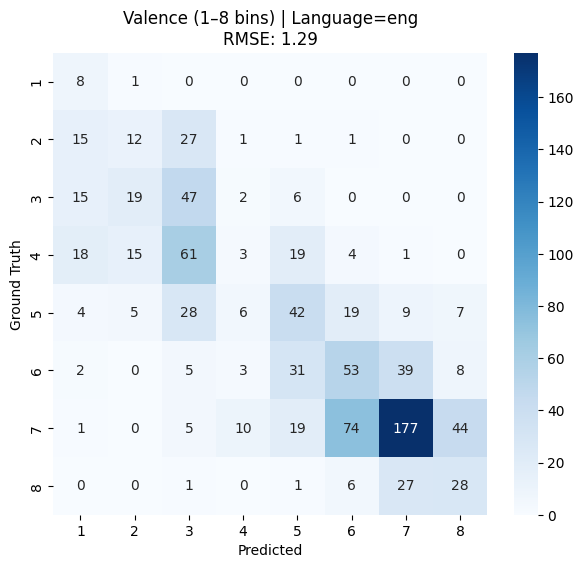


==================== Valence (1–8 bins) | Language=jpn ====================
RMSE: 1.1303
------------------------------------------------------------
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00        10
           3       0.53      0.46      0.49        57
           4       0.00      0.00      0.00        46
           5       0.17      0.86      0.29        29
           6       0.59      0.16      0.25       190
           7       0.38      0.58      0.46        85
           8       0.00      0.00      0.00         1

    accuracy                           0.31       418
   macro avg       0.21      0.26      0.19       418
weighted avg       0.43      0.31      0.29       418

------------------------------------------------------------


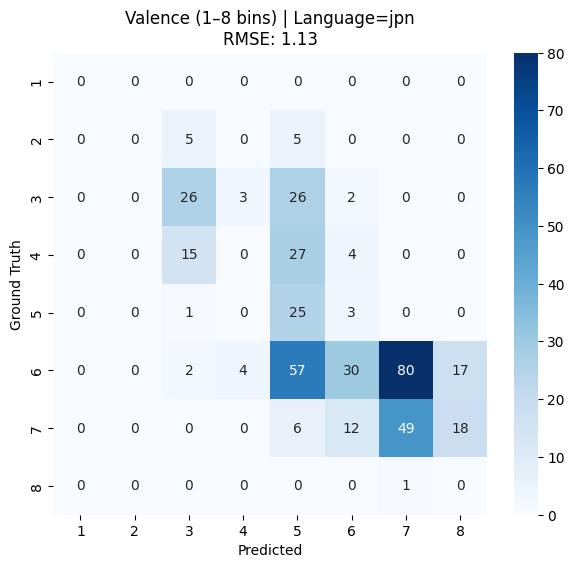


==================== Valence (1–8 bins) | Language=rus ====================
RMSE: 1.1558
------------------------------------------------------------
              precision    recall  f1-score   support

           1       0.20      0.33      0.25         3
           2       0.00      0.00      0.00        19
           3       0.31      0.69      0.43        16
           4       0.00      0.00      0.00         2
           5       0.19      0.75      0.31         8
           6       0.41      0.39      0.40        56
           7       0.59      0.50      0.54       115
           8       0.48      0.41      0.44        49

    accuracy                           0.44       268
   macro avg       0.27      0.38      0.30       268
weighted avg       0.45      0.44      0.43       268

------------------------------------------------------------


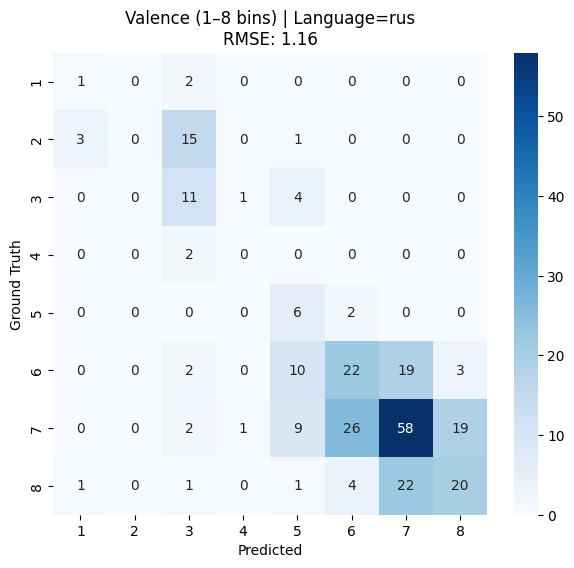


==================== Valence (1–8 bins) | Language=ukr ====================
RMSE: 1.1857
------------------------------------------------------------
              precision    recall  f1-score   support

           1       0.50      0.67      0.57         6
           2       0.00      0.00      0.00        14
           3       0.19      0.55      0.29        11
           4       0.33      0.25      0.29         8
           5       0.08      0.25      0.12         8
           6       0.32      0.28      0.30        53
           7       0.56      0.50      0.53       101
           8       0.46      0.39      0.43        33

    accuracy                           0.39       234
   macro avg       0.31      0.36      0.31       234
weighted avg       0.42      0.39      0.40       234

------------------------------------------------------------


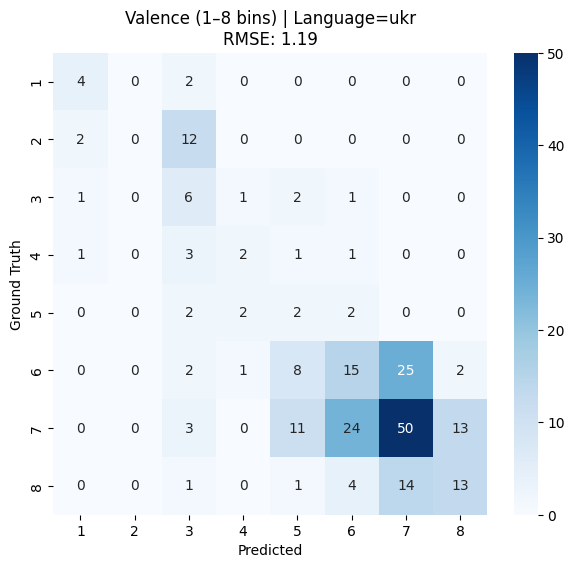


==================== Valence (1–8 bins) | Language=zho ====================
RMSE: 1.1063
------------------------------------------------------------
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           2       0.12      0.17      0.14        12
           3       0.29      0.61      0.39       118
           4       0.46      0.07      0.12       250
           5       0.45      0.48      0.47       398
           6       0.65      0.31      0.42       891
           7       0.14      0.51      0.21       140
           8       0.00      0.00      0.00         0

    accuracy                           0.35      1809
   macro avg       0.26      0.27      0.22      1809
weighted avg       0.51      0.35      0.37      1809

------------------------------------------------------------


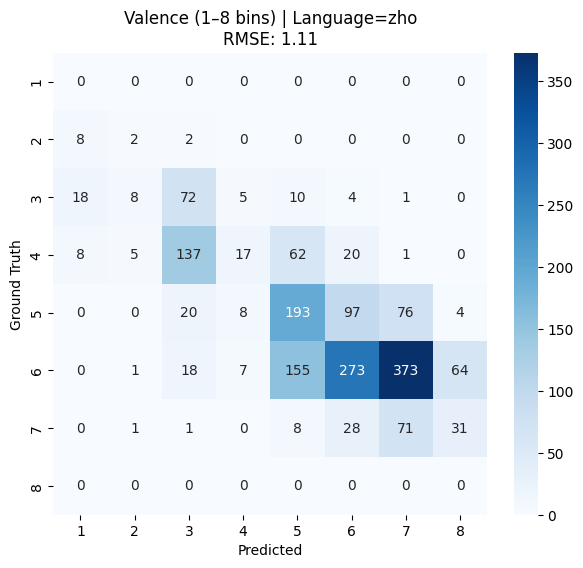


==================== Valence (1–8 bins) | Domain=finance ====================
RMSE: 1.1025
------------------------------------------------------------
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         6
           3       0.42      0.42      0.42        48
           4       0.00      0.00      0.00        62
           5       0.40      0.74      0.52       155
           6       0.51      0.15      0.23       150
           7       0.00      0.00      0.00         6
           8       0.00      0.00      0.00         0

    accuracy                           0.37       427
   macro avg       0.17      0.16      0.15       427
weighted avg       0.37      0.37      0.31       427

------------------------------------------------------------


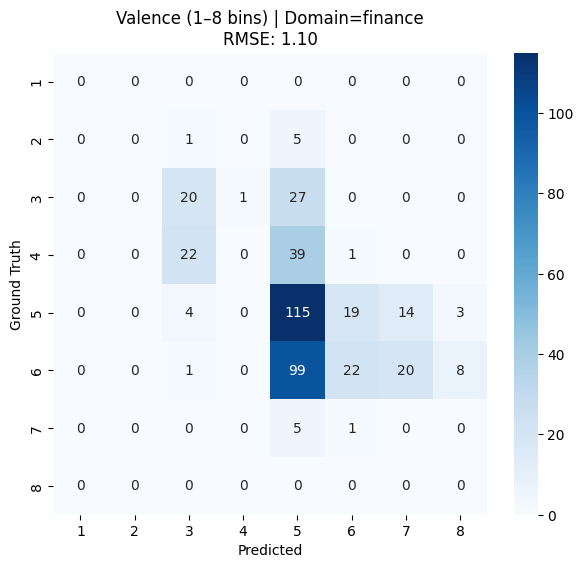


==================== Valence (1–8 bins) | Domain=hotel ====================
RMSE: 1.0520
------------------------------------------------------------
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         4
           3       0.59      0.77      0.67        22
           4       0.00      0.00      0.00        11
           5       0.07      0.33      0.11         3
           6       0.54      0.17      0.26       131
           7       0.38      0.60      0.47        81
           8       0.00      0.00      0.00         1

    accuracy                           0.35       253
   macro avg       0.20      0.23      0.19       253
weighted avg       0.45      0.35      0.34       253

------------------------------------------------------------


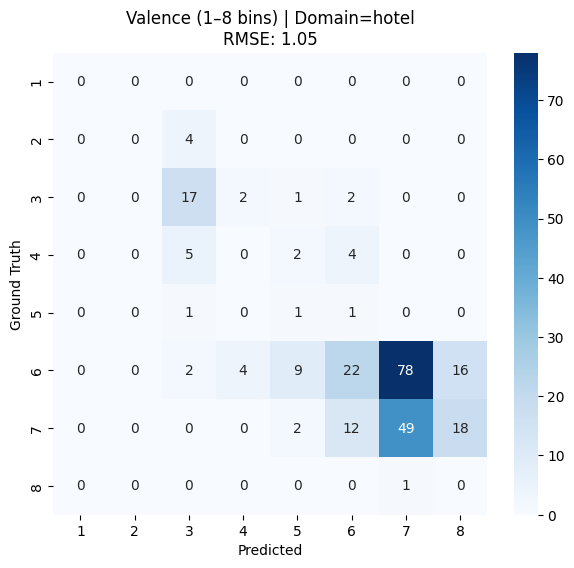


==================== Valence (1–8 bins) | Domain=laptop ====================
RMSE: 1.2058
------------------------------------------------------------
              precision    recall  f1-score   support

           1       0.07      1.00      0.13         4
           2       0.27      0.25      0.26        51
           3       0.29      0.56      0.38       117
           4       0.35      0.06      0.11       190
           5       0.32      0.44      0.37       174
           6       0.54      0.38      0.44       416
           7       0.46      0.50      0.48       276
           8       0.21      0.41      0.28        34

    accuracy                           0.38      1262
   macro avg       0.31      0.45      0.31      1262
weighted avg       0.42      0.38      0.37      1262

------------------------------------------------------------


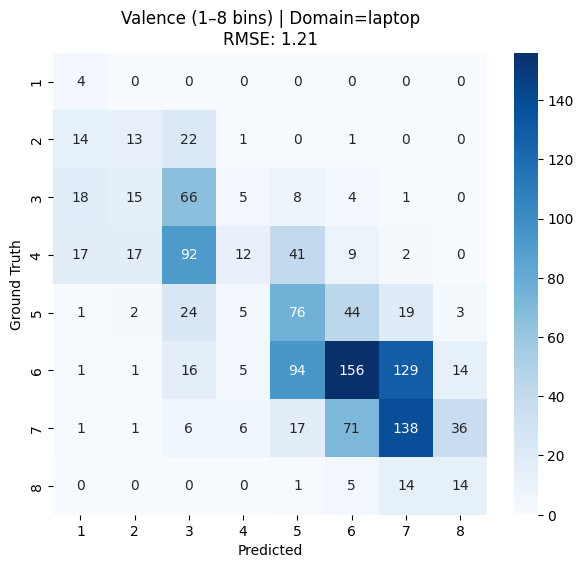


==================== Valence (1–8 bins) | Domain=restaurant ====================
RMSE: 1.1684
------------------------------------------------------------
              precision    recall  f1-score   support

           1       0.17      0.64      0.26        14
           2       0.05      0.02      0.03        51
           3       0.25      0.57      0.35       104
           4       0.28      0.06      0.10       164
           5       0.37      0.33      0.35       231
           6       0.54      0.30      0.39       634
           7       0.35      0.53      0.42       408
           8       0.26      0.42      0.32       111

    accuracy                           0.36      1717
   macro avg       0.28      0.36      0.28      1717
weighted avg       0.39      0.36      0.35      1717

------------------------------------------------------------


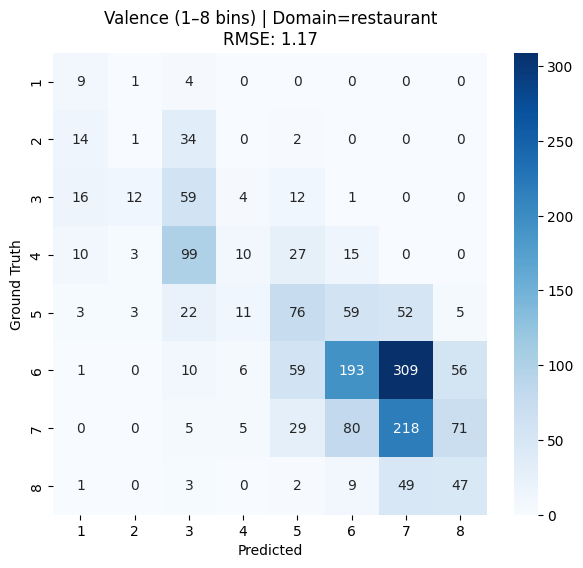

In [58]:
numeric_labels = list(range(1, 9))

run_all_slices(
    test_with_preds,
    'true_v_bin',
    'pred_v_bin',
    'Valence (1–8 bins)',
    labels=numeric_labels,
    compute_rmse=True
)

# run_all_slices(
#     test_with_preds,
#     'true_a_bin',
#     'pred_a_bin',
#     'Arousal (1–8 bins)',
#     labels=numeric_labels,
#     compute_rmse=True
# )



==================== Valence (Coarse A/B/C) (Overall) ====================
------------------------------------------------------------
              precision    recall  f1-score   support

           A       0.31      0.43      0.36       130
           B       0.66      0.71      0.68      1281
           C       0.88      0.83      0.85      2248

    accuracy                           0.77      3659
   macro avg       0.62      0.65      0.63      3659
weighted avg       0.78      0.77      0.78      3659

------------------------------------------------------------


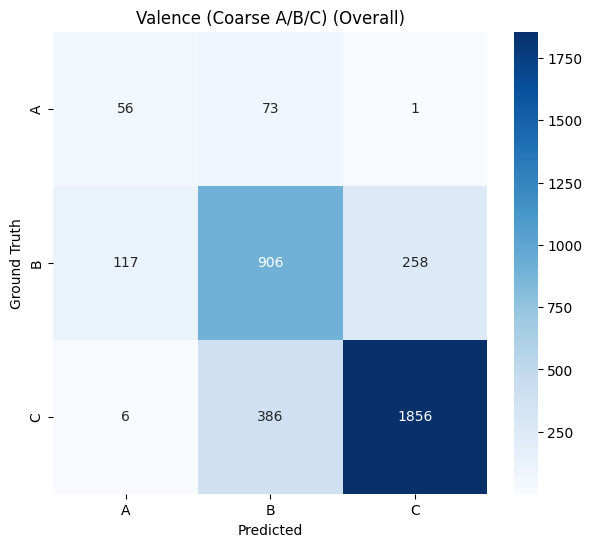


==================== Valence (Coarse A/B/C) | Language=eng ====================
------------------------------------------------------------
              precision    recall  f1-score   support

           A       0.31      0.55      0.40        66
           B       0.67      0.65      0.66       330
           C       0.92      0.85      0.88       534

    accuracy                           0.76       930
   macro avg       0.63      0.68      0.65       930
weighted avg       0.79      0.76      0.77       930

------------------------------------------------------------


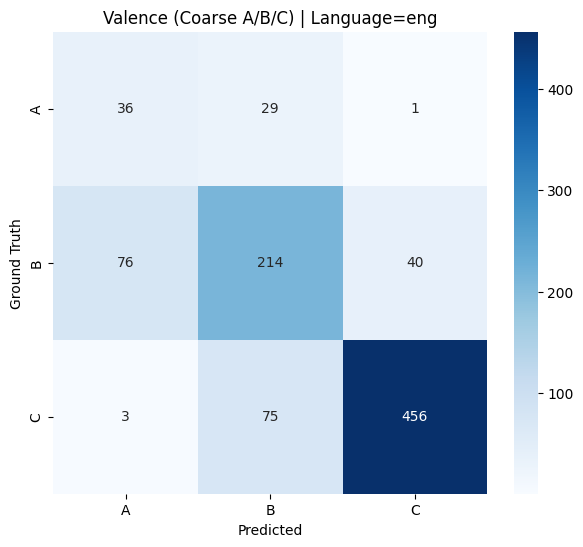


==================== Valence (Coarse A/B/C) | Language=jpn ====================
------------------------------------------------------------
              precision    recall  f1-score   support

           A       0.00      0.00      0.00        10
           B       0.61      0.93      0.74       132
           C       0.96      0.75      0.84       276

    accuracy                           0.79       418
   macro avg       0.52      0.56      0.53       418
weighted avg       0.83      0.79      0.79       418

------------------------------------------------------------


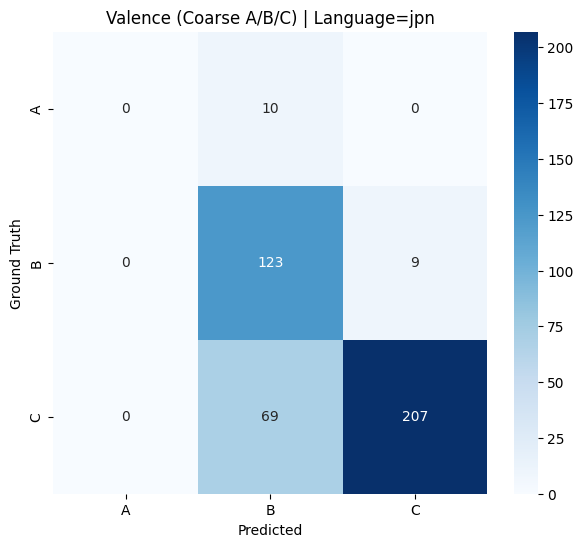


==================== Valence (Coarse A/B/C) | Language=rus ====================
------------------------------------------------------------
              precision    recall  f1-score   support

           A       0.80      0.18      0.30        22
           B       0.35      0.92      0.51        26
           C       0.99      0.88      0.93       220

    accuracy                           0.82       268
   macro avg       0.71      0.66      0.58       268
weighted avg       0.91      0.82      0.84       268

------------------------------------------------------------


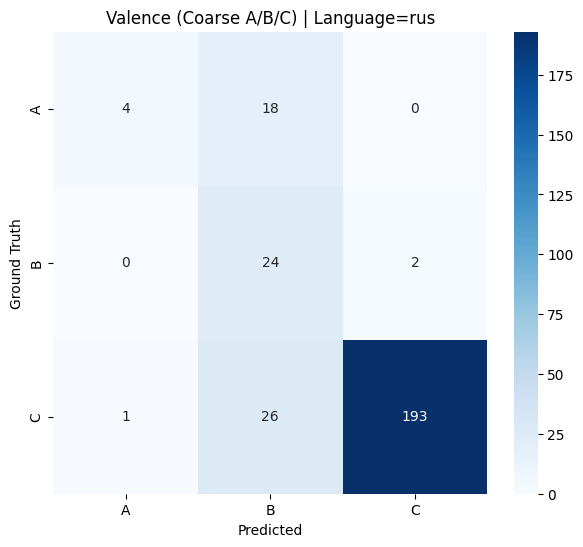


==================== Valence (Coarse A/B/C) | Language=ukr ====================
------------------------------------------------------------
              precision    recall  f1-score   support

           A       0.75      0.30      0.43        20
           B       0.34      0.78      0.47        27
           C       0.98      0.86      0.91       187

    accuracy                           0.80       234
   macro avg       0.69      0.64      0.60       234
weighted avg       0.88      0.80      0.82       234

------------------------------------------------------------


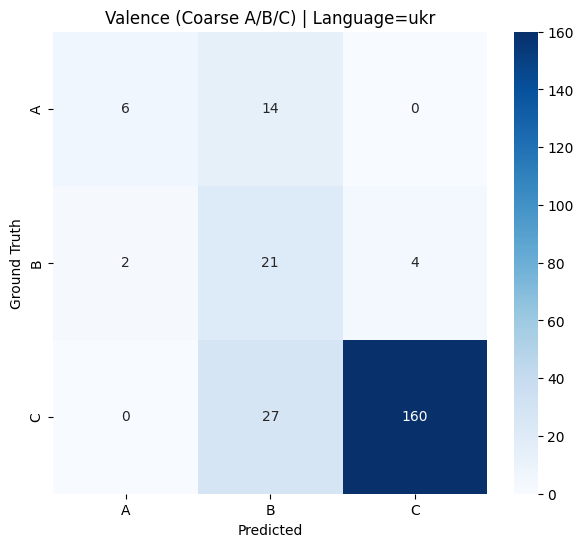


==================== Valence (Coarse A/B/C) | Language=zho ====================
------------------------------------------------------------
              precision    recall  f1-score   support

           A       0.20      0.83      0.32        12
           B       0.73      0.68      0.71       766
           C       0.81      0.81      0.81      1031

    accuracy                           0.76      1809
   macro avg       0.58      0.78      0.61      1809
weighted avg       0.77      0.76      0.76      1809

------------------------------------------------------------


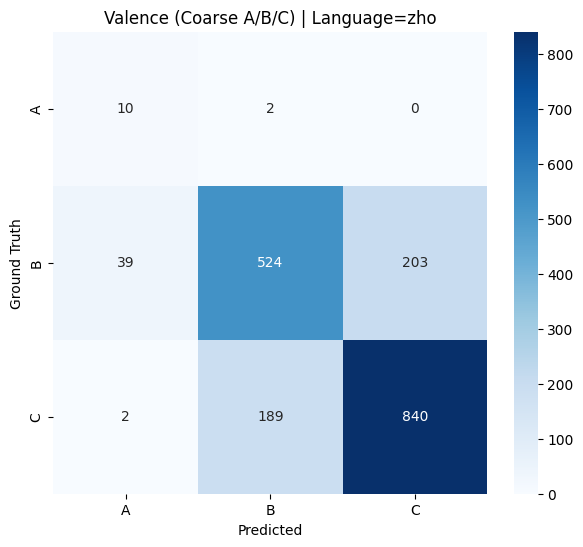


==================== Valence (Coarse A/B/C) | Domain=finance ====================
------------------------------------------------------------
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         6
           B       0.67      0.86      0.75       265
           C       0.58      0.33      0.42       156

    accuracy                           0.65       427
   macro avg       0.42      0.40      0.39       427
weighted avg       0.63      0.65      0.62       427

------------------------------------------------------------


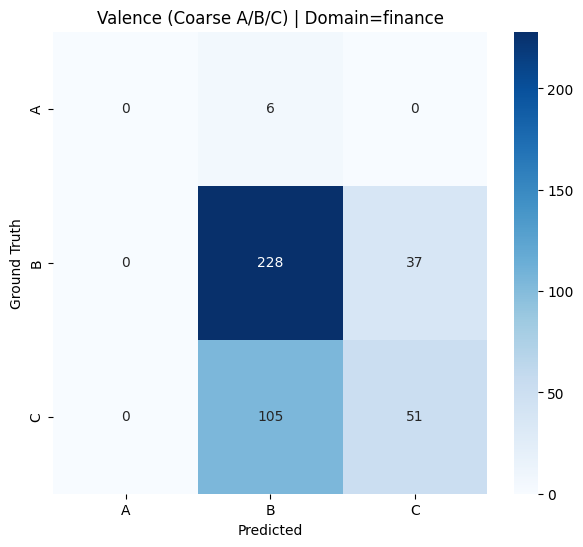


==================== Valence (Coarse A/B/C) | Domain=hotel ====================
------------------------------------------------------------
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         4
           B       0.58      0.81      0.67        36
           C       0.97      0.92      0.94       213

    accuracy                           0.89       253
   macro avg       0.52      0.58      0.54       253
weighted avg       0.90      0.89      0.89       253

------------------------------------------------------------


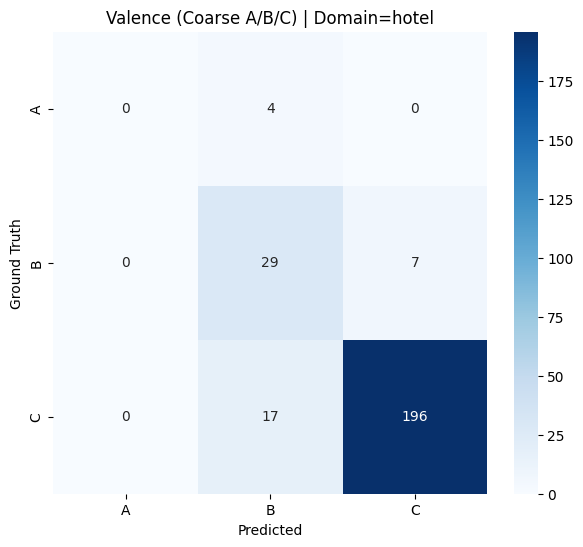


==================== Valence (Coarse A/B/C) | Domain=laptop ====================
------------------------------------------------------------
              precision    recall  f1-score   support

           A       0.30      0.56      0.39        55
           B       0.66      0.68      0.67       481
           C       0.87      0.79      0.83       726

    accuracy                           0.74      1262
   macro avg       0.61      0.68      0.63      1262
weighted avg       0.77      0.74      0.75      1262

------------------------------------------------------------


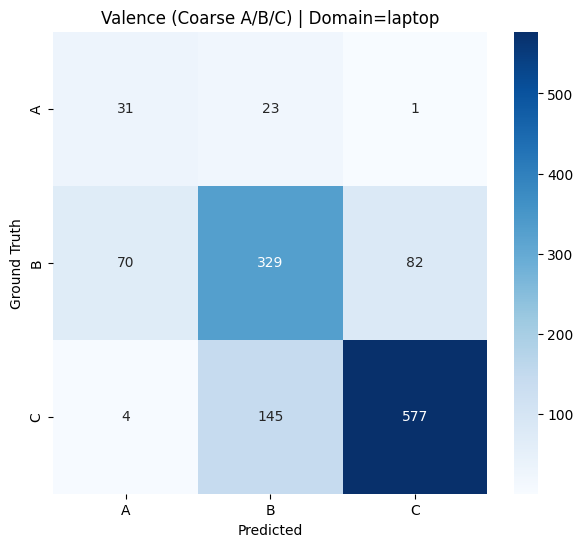


==================== Valence (Coarse A/B/C) | Domain=restaurant ====================
------------------------------------------------------------
              precision    recall  f1-score   support

           A       0.34      0.38      0.36        65
           B       0.67      0.64      0.65       499
           C       0.89      0.90      0.89      1153

    accuracy                           0.80      1717
   macro avg       0.63      0.64      0.63      1717
weighted avg       0.80      0.80      0.80      1717

------------------------------------------------------------


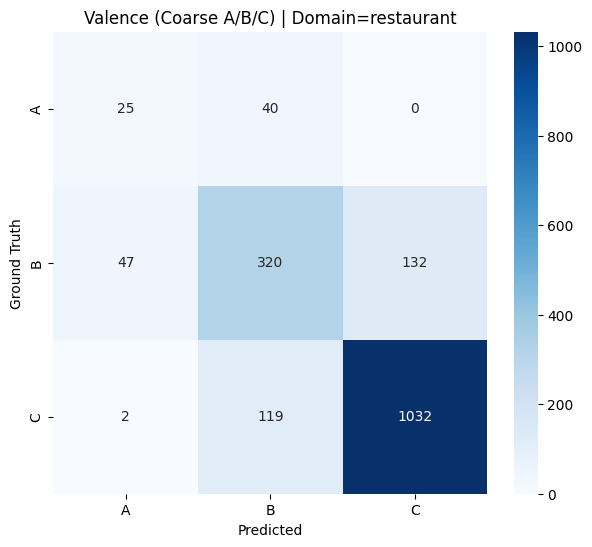

In [59]:
coarse_labels = ['A', 'B', 'C']

run_all_slices(
    test_with_preds,
    'true_v_bin_coarse',
    'pred_v_bin_coarse',
    'Valence (Coarse A/B/C)',
    labels=coarse_labels,
    compute_rmse=False
)

In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, classification_report, confusion_matrix

# === STEP 1: APPLY DRIFT LOGIC ===
def apply_drift(row, bin_col, drift_col):
    """
    Applies the drift logic:
    Drift 1 -> Subtract 0.5 (Lean Lower)
    Drift 2 -> Add 0.5 (Lean Higher)
    Drift 3 -> No Change (Confident)
    """
    base_val = row[bin_col]
    drift_val = row[drift_col]
    
    if drift_val == 1:
        return base_val - 1
    elif drift_val == 2:
        return base_val + 1
    else:
        return base_val # Drift 3 or NaN

# Apply logic to create new Float columns
# Note: Ensure your dataframe actually has 'pred_v_drift' and 'pred_a_drift' columns.
# If your drift column is named differently, update the 'drift_col' argument below.

test_with_preds['pred_v_adjusted'] = test_with_preds.apply(
    lambda x: apply_drift(x, 'pred_v_bin', 'pred_drift'), axis=1
)

# test_withh_preds['pred_a_adjusted'] =test_withh_preds.apply(
#     lambda x: apply_drift(x, 'pred_a_bin', 'pred_a_drift'), axis=1
# )

# === STEP 2: METRICS FUNCTION ===

def analyze_drift_results(y_true, y_pred_int, y_pred_adj, title):
    """
    y_true: Ground Truth Integers
    y_pred_int: The original Integer predictions (for Confusion Matrix)
    y_pred_adj: The drift-adjusted Float predictions (for RMSE)
    """
    # 1. Calculate RMSE using the NUANCED (Adjusted) values
    # We compare the integer Ground Truth vs the Float Prediction (e.g. 7 vs 7.5)
    mask = np.isfinite(y_true) & np.isfinite(y_pred_adj)
    rmse = np.sqrt(mean_squared_error(y_true[mask], y_pred_adj[mask]))
    
    # 2. Calculate Classification Report using INTEGER values
    # (Classification metrics don't make sense with 4.5 vs 4)
    report = classification_report(
        y_true[mask], 
        y_pred_int[mask], 
        labels=range(1, 9), 
        zero_division=0
    )
    
    print(f"\n{'='*20} {title} {'='*20}")
    print(f"RMSE (Using Drift Adjustments): {rmse:.4f}")
    print("-" * 60)
    print("Classification Report (Based on dominant bin):")
    print(report)
    print("-" * 60)

    # 3. Plot Confusion Matrix (Integer vs Integer)
    cm = confusion_matrix(y_true[mask], y_pred_int[mask], labels=range(1, 9))
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(1,9), yticklabels=range(1,9))
    plt.xlabel('LLM Predicted Bin (Integer)')
    plt.ylabel('Ground Truth Bin')
    plt.title(f"{title}\nAdjusted RMSE: {rmse:.4f}") 
    plt.show()

# === STEP 3: RUN ANALYSIS ===

# Ensure Ground Truth is ready
test_with_preds['true_v_bin'] = np.floor(pd.to_numeric(test_with_preds['Valence'], errors='coerce')).fillna(5).astype(int).clip(1, 8)
test_with_preds['true_a_bin'] = np.floor(pd.to_numeric(test_with_preds['Arousal'], errors='coerce')).fillna(5).astype(int).clip(1, 8)

# Run Valence Analysis
analyze_drift_results(
    test_with_preds['true_v_bin'],      # Truth
    test_with_preds['pred_v_bin'],      # Original Int (for Matrix)
    test_with_preds['pred_v_adjusted'], # Drift Float (for RMSE)
    "Valence: Drift-Adjusted"
)

# Run Arousal Analysis
# analyze_drift_results(
#     test_with_preds['true_a_bin'],      # Truth
#     test_with_preds['pred_a_bin'],      # Original Int (for Matrix)
#     test_with_preds['pred_a_adjusted'], # Drift Float (for RMSE)
#     "Arousal: Drift-Adjusted"
# )

KeyError: 'pred_drift'

[2026-01-05 13:59:36] INFO category.py:224: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/tmp/ipykernel_913601/1183069006.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Prediction', y='Ground Truth', data=plot_df, ax=axes[1], palette="coolwarm")
[2026-01-05 13:59:36] INFO category.py:224: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-01-05 13:59:36] INFO category.py:224: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data typ


==================== Valence: Continuous Ground Truth vs LLM Bins ====================
RMSE (Root Mean Sq Error): 1.1730
MAE  (Mean Absolute Error): 0.8174
Pearson Correlation (r):    0.8444
------------------------------------------------------------


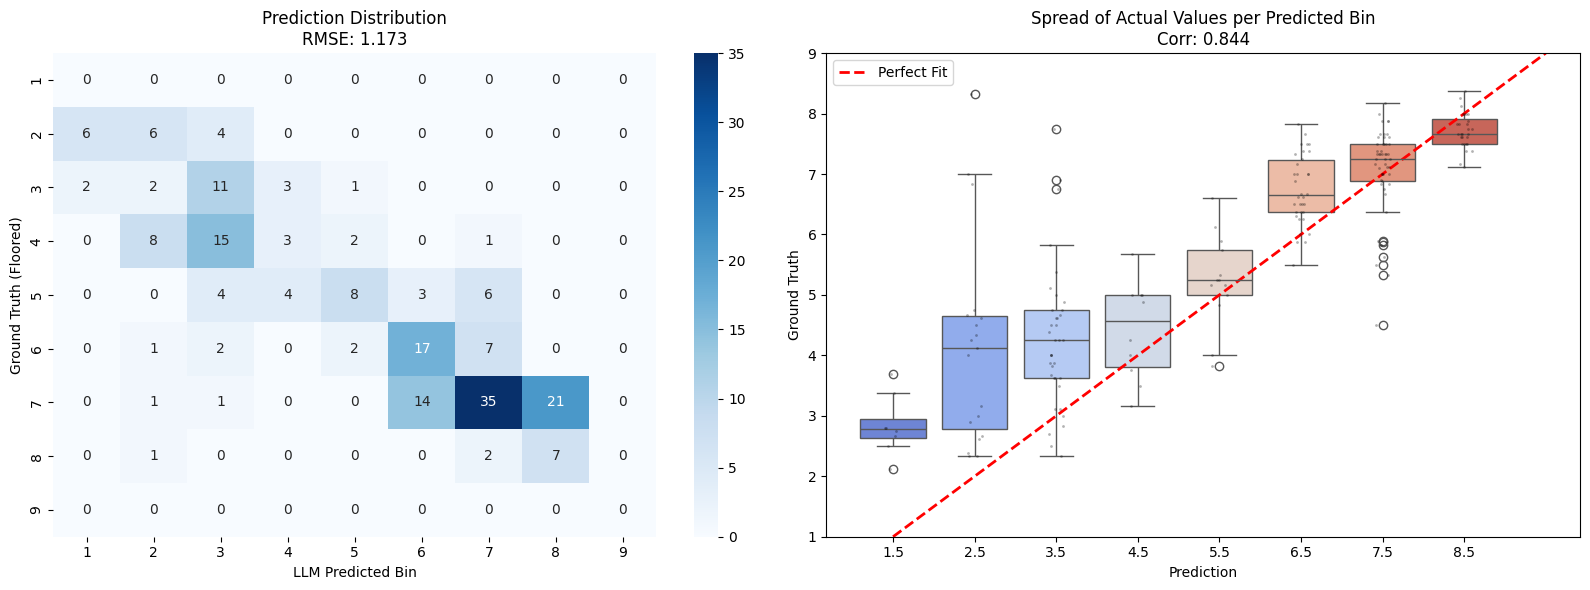

/home/modim2/.conda/envs/pyllm/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/modim2/.conda/envs/pyllm/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
[2026-01-05 13:59:36] INFO category.py:224: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/tmp/ipykernel_913601/1183069006.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Prediction', y='Ground Truth', data=plot_df, ax=axes[1], palette="coolwarm")
[2026-01-05 13:59:36] INFO category.py:224: Using categorical units to plot a list of strings that ar


==================== Arousal: Continuous Ground Truth vs LLM Bins ====================
RMSE (Root Mean Sq Error): 1.4695
MAE  (Mean Absolute Error): 1.2417
Pearson Correlation (r):    nan
------------------------------------------------------------


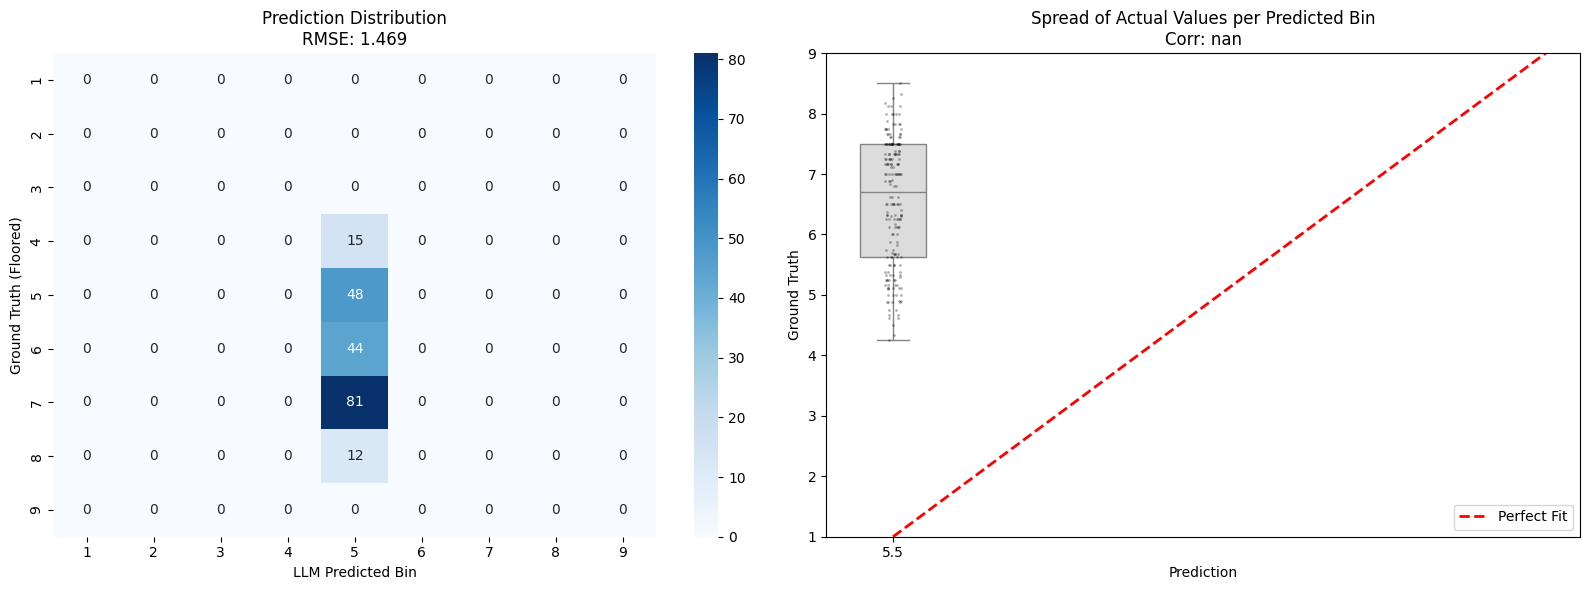

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Ensure numeric types for calculation
# Ground Truth: Keep as exact floats (e.g., 7.3, 1.5)
test_with_preds['true_v_float'] = pd.to_numeric(test_with_preds['Valence'], errors='coerce')
test_with_preds['true_a_float'] = pd.to_numeric(test_with_preds['Arousal'], errors='coerce')

# Predictions: Treat bin integers as float values (e.g., Bin 7 becomes 7.0)
test_with_preds['pred_v_float'] = pd.to_numeric(test_with_preds['pred_v_bin'], errors='coerce')
test_with_preds['pred_a_float'] = pd.to_numeric(test_with_preds['pred_a_bin'], errors='coerce')

# test_with_preds['pred_v_float'] = test_with_preds['pred_v_float'] + 0.5
# test_with_preds['pred_a_float'] = test_with_preds['pred_a_float'] + 0.5

def analyze_continuous_vs_bin(y_true, y_pred, title):
    # Create mask for valid data (drop NaNs in either column)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_pred = y_pred + 0.50
    y_true_clean = y_true[mask]
    y_pred_clean = y_pred[mask]
    
    if len(y_true_clean) == 0:
        print(f"[{title}] Error: No valid data points.")
        return

    # === METRICS (Continuous) ===
    # RMSE: Calculates error based on exact distance 
    # (e.g. Truth 7.8 vs Pred 7.0 results in 0.8 error, not 0)
    rmse = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
    mae = mean_absolute_error(y_true_clean, y_pred_clean)
    
    # Pearson Correlation: How well does the trend match?
    correlation = np.corrcoef(y_true_clean, y_pred_clean)[0, 1]

    print(f"\n{'='*20} {title} {'='*20}")
    print(f"RMSE (Root Mean Sq Error): {rmse:.4f}")
    print(f"MAE  (Mean Absolute Error): {mae:.4f}")
    print(f"Pearson Correlation (r):    {correlation:.4f}")
    print("-" * 60)

    # === PLOTTING ===
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # PLOT 1: Confusion Heatmap (Visualizing Density)
    # We bin the ground truth JUST for the visualization to make a matrix
    y_true_binned = np.floor(y_true_clean).clip(1, 9).astype(int)
    y_pred_int = y_pred_clean.astype(int)
    
    # Generate matrix manually to ensure all 1-9 labels exist
    bins = range(1, 10) # 1 through 9
    cm = confusion_matrix(y_true_binned, y_pred_int, labels=bins)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=bins, yticklabels=bins, ax=axes[0])
    axes[0].set_xlabel('LLM Predicted Bin')
    axes[0].set_ylabel('Ground Truth (Floored)')
    axes[0].set_title(f'Prediction Distribution\nRMSE: {rmse:.3f}')

    # PLOT 2: Box Plot (The Standard for Discrete vs Continuous)
    # This shows the SPREAD of actual float values for every bin the LLM predicted
    plot_df = pd.DataFrame({'Prediction': y_pred_clean, 'Ground Truth': y_true_clean})
    sns.boxplot(x='Prediction', y='Ground Truth', data=plot_df, ax=axes[1], palette="coolwarm")
    sns.stripplot(x='Prediction', y='Ground Truth', data=plot_df, 
                  color='black', alpha=0.3, size=2, jitter=True, ax=axes[1])
    
    # Add identity line (perfect prediction line)
    axes[1].plot([0, 8], [1, 9], 'r--', lw=2, label='Perfect Fit')
    axes[1].set_title(f'Spread of Actual Values per Predicted Bin\nCorr: {correlation:.3f}')
    axes[1].set_ylim(1, 9)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# Run Analysis
from sklearn.metrics import confusion_matrix # Re-importing inside just in case

analyze_continuous_vs_bin(
    test_with_preds['true_v_float'], 
    test_with_preds['pred_v_float'], 
    "Valence: Continuous Ground Truth vs LLM Bins"
)

analyze_continuous_vs_bin(
    test_with_preds['true_a_float'], 
    test_with_preds['pred_a_float'], 
    "Arousal: Continuous Ground Truth vs LLM Bins"
)